Firts execute the requirements with "sudo sh requirements"

In [3]:
!pip install kagglehub
!pip install contractions
!pip install nltk
!pip install stanza

In [4]:
import stanza
from stanza.models.common.doc import Document
import contractions
import re
import json
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import time
import random
import shutil
import collections
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter, defaultdict
import math
import kagglehub

/home/bramen/Documentos/jupyer/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:

# Download latest version
path = kagglehub.dataset_download("jef1056/anime-subtitles")

print(path)

# Ruta donde se descargaron los archivos
folder = path + "/Anime Datasets V4/Preprocessed/Preprocessed"

# Crear carpeta de destino
ANIME_SUBS = "anime_subs"
os.makedirs(ANIME_SUBS, exist_ok=True)

# Copiar los archivos a la carpeta anime_subs
for file_name in os.listdir(folder):
    file_path = os.path.join(folder, file_name)
    if os.path.isfile(file_path):  # Asegurar que sea un archivo
        shutil.copy(file_path, ANIME_SUBS)

print(f"Archivos copiados a {ANIME_SUBS}")



/home/bramen/.cache/kagglehub/datasets/jef1056/anime-subtitles/versions/24
Archivos copiados a anime_subs


In [6]:
stanza.download("en")
nlp_stanza = stanza.Pipeline(lang="en", processors="tokenize")

2025-04-01 19:56:40 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 19:56:40 INFO: Downloading default packages for language: en (English) ...
2025-04-01 19:56:45 INFO: File exists: /home/bramen/stanza_resources/en/default.zip
2025-04-01 19:56:51 INFO: Finished downloading models and saved to /home/bramen/stanza_resources
2025-04-01 19:56:51 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-04-01 19:56:51 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 19:56:51 WARNING: Language en package default expects mwt, which has been added
2025-04-01 19:56:51 INFO: Loading these models for language: en (English):
| Processor | Package  |
------------------------
| tokenize  | combined |
| mwt       | combined |

2025-04-01 19:56:51 INFO: Using device: cpu
2025-04-01 19:56:51 INFO: Lo

Change the json files into .txt ones.

Execute this code if the files aren't created (they normally already are)

In [7]:
def expand_contractions(text):
    return contractions.fix(text)

In [8]:
def normalization(content: str) -> str:
    """Expande contracciones y normaliza el texto eliminando caracteres no alfabéticos."""
    norm_content = contractions.fix(content)
    return norm_content


In [9]:
def clean_text(text):
    """Converts to lowercase and removes non-alphabetic characters (except spaces)."""
    return re.sub(r"[^a-zA-Z\s]", "", text).lower().strip()

In [10]:
def create_corpus(words: list, noise=True):
    with open("corpus.txt", "a", encoding="utf-8") as new_file:
        if noise:
            content = "\n".join(words).strip() + "\n"
        else:
            result = "\n".join(filter(None, [clean_text(word) for word in words]))
            if result:  # Solo escribe si no está vacío
                content = result + "\n"
            else:
                return  # Evita escribir líneas vacías

        new_file.write(content)

In [11]:
def clean_corpus():
    # Leer el archivo y convertirlo en una lista
    with open("corpus.txt", "r", encoding="utf-8") as file:
        words = file.read().splitlines()  # Convierte cada línea en un elemento de la lista

    # Eliminar palabras repetidas con un set y volver a lista ordenada
    unique_words = sorted(set(words))

    # Guardar las palabras únicas en un nuevo archivo
    with open("corpus_unique.txt", "w", encoding="utf-8") as file:
        file.write("\n".join(unique_words))

    print("Proceso completado. Se guardaron", len(unique_words), "palabras únicas en 'corpus_unique.txt'.")


In [69]:
def segmentar_phrases(conversations, file_name):
    with open(file_name, "w", encoding="utf-8") as new_file:
        content_list = []
        for line in json.loads(conversations).get("conversations")[0]:
            for text in line:
                line_stanza: Document = nlp_stanza(normalization(text))

                phrases = [sentence.text for sentence in line_stanza.sentences]
                words = [word.text for sentence in line_stanza.sentences for word in sentence.words]

                create_corpus(words, False)

                contetn_json = {
                    text : {
                        "phrases": phrases,
                        "words": words
                        }
                }
                content_list.append(contetn_json)
        json.dump(content_list, new_file, indent=4, ensure_ascii=False)


1. Normalicen el formato de sus textos: 
    i) pasen todos los textos a letras minusculas; 
    ii) eliminen o reemplacen caracteres especiales, śımbolos y emojis.
2. Segmenten sus documentos a nivel de frase y palabra. Guarden el resultado en archivos separados.
3. Eliminen signos de puntuacion y caracteres no alfabeticos. Calculen el numero de tokens y palabras distintas en sus textos.

In [71]:

ANIME_SUBS_JSON = "anime_subs_json"
os.makedirs(ANIME_SUBS_JSON, exist_ok=True)

file_list = os.listdir(ANIME_SUBS)

contador = 0

for filename in file_list:
    filename_input = os.path.join(ANIME_SUBS, filename)
    filename_output = os.path.join(ANIME_SUBS_JSON, filename)
    with open(filename_input, "r", encoding="utf-8") as new_file:
        segmentar_phrases(new_file.read(), filename_output)
    
    contador += 1
    print(f"{contador} de {len(file_list)} procesados")

314 de 3836 procesados
315 de 3836 procesados
316 de 3836 procesados
317 de 3836 procesados
318 de 3836 procesados
319 de 3836 procesados
320 de 3836 procesados
321 de 3836 procesados
322 de 3836 procesados
323 de 3836 procesados
324 de 3836 procesados
325 de 3836 procesados
326 de 3836 procesados
327 de 3836 procesados
328 de 3836 procesados
329 de 3836 procesados
330 de 3836 procesados
331 de 3836 procesados
332 de 3836 procesados
333 de 3836 procesados
334 de 3836 procesados
335 de 3836 procesados
336 de 3836 procesados
337 de 3836 procesados
338 de 3836 procesados
339 de 3836 procesados
340 de 3836 procesados
341 de 3836 procesados
342 de 3836 procesados
343 de 3836 procesados
344 de 3836 procesados
345 de 3836 procesados
346 de 3836 procesados
347 de 3836 procesados
348 de 3836 procesados
349 de 3836 procesados
350 de 3836 procesados
351 de 3836 procesados
352 de 3836 procesados
353 de 3836 procesados
354 de 3836 procesados
355 de 3836 procesados
356 de 3836 procesados
357 de 3836

1. Noralization
This script normalizes the text format in JSON subtitle files by:

Converting all text to lowercase.
Removing special characters, symbols, and emojis.
It processes:

The keys (original phrases).
The "phrases" list.
The "words" list (removing empty elements after cleaning).
The cleaned JSON files overwrite the originals in the 'animes_subs/' folder.

In [73]:
folder_path = "anime_subs_json"

def clean_json_files():
    """Cleans subtitles in JSON files inside 'animes_subs/' and overwrites them."""
    
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder '{folder_path}' not found.")
        return  

    file_list = os.listdir(folder_path)
    counter = 0

    for filename in file_list:
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            cleaned_data = []
            
            for entry in data:
                for original_text, content in entry.items():
                    cleaned_text = clean_text(original_text)

                    content["words"]

                    cleaned_entry = {
                        cleaned_text: {
                            "phrases": [clean_text(phrase) for phrase in content["phrases"]],
                            "words": [clean_text(word) for word in content["words"] if clean_text(word)]
                        }
                    }
                    
                    cleaned_data.append(cleaned_entry)

            with open(file_path, "w", encoding="utf-8") as f:
                json.dump(cleaned_data, f, ensure_ascii=False, indent=4)

            counter +=1
            
            print(f"{counter}/{len(file_list)}", f"✅ {filename} cleaned and updated.")

In [74]:
clean_json_files()

1/3836 ✅ [Ayako-BakaWolf]_Rosario___Vampire_-_13_-_[H264][1280x720]_[7608B35D].json cleaned and updated.
2/3836 ✅ DBZ - 050 - Unexpected Problem.json cleaned and updated.
3/3836 ✅ [HorribleSubs] Sora yori mo Tooi Basho - 12 [720p]_track3_eng.json cleaned and updated.
4/3836 ✅ - AMG 11 - [Exiled-Destiny] _ Ah! A Demon has Come and is Creating Calamity_Track5.json cleaned and updated.
5/3836 ✅ [HorribleSubs] Sakurasou no Pet na Kanojo - 10 [720p].json cleaned and updated.
6/3836 ✅ [Coalgirls] Darker than Black - 08 (BD 1280x720 x264  FLAC).json cleaned and updated.
7/3836 ✅ [Coalgirls]_Darker_than_Black_-_Ryuusei_no_Gemini_07_(1280x720_Blu-Ray_FLAC)_[0CC6D95A].json cleaned and updated.
8/3836 ✅ [TMD_A-Destiny]_Bakuman_05_[720p][04D19245].json cleaned and updated.
9/3836 ✅ [HorribleSubs] Mob Psycho 100 - 06 [720p]_track3_eng.json cleaned and updated.
10/3836 ✅ [HorribleSubs] Yahari Ore no Seishun Love Come wa Machigatteiru Zoku - 10 [720p].json cleaned and updated.
11/3836 ✅ [Horriblesubs

3. Count tokens
This script calculates:

The total number of tokens (all words, including repetitions).
The number of unique words (distinct words after normalization).
It processes all JSON subtitle files in 'animes_subs/' by:

Extracting words from the "phrases" and "words" lists.
Cleaning and counting them.
Printing the final statistics.
Tokens represent the total word occurrences, while unique words count distinct vocabulary items.

In [77]:
folder_path = "anime_subs_json/"

def count_tokens_and_unique_words():
    """Counts total tokens and unique words in all JSON subtitle files."""
    
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder '{folder_path}' not found.")
        return  

    total_tokens = 0
    unique_words = set()

    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            for entry in data:
                for content in entry.values():
                    # Count tokens (all words)
                    tokens = [word for phrase in content["phrases"] for word in phrase.split()]
                    total_tokens += len(tokens)
                    
                    # Add words to the unique set
                    words = [clean_text(word) for word in content["words"] if clean_text(word)]
                    unique_words.update(words)

    print(f"📊 Total tokens: {total_tokens}")
    print(f"📌 Unique words: {len(unique_words)}")

count_tokens_and_unique_words()

📊 Total tokens: 8960343
📌 Unique words: 59171


4.Removing Stop-Words and Recalculating Tokens & Vocabulary
This script processes anime subtitle files by removing common stop-words and comparing the impact on token count and vocabulary size.

Steps:
Load predefined stop-words (NLTK's English stop-word list).
Extract and clean text from the JSON files.
Count tokens and unique words before stop-word removal.
Filter out stop-words from both "phrases" and "words".
Recalculate tokens and vocabulary size after cleaning.
Compare the results, showing the number of removed words.
By removing stop-words, the dataset retains only meaningful content, improving text analysis efficiency.

In [78]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

folder_path = "anime_subs_json/"

def count_tokens_and_vocab(remove_stopwords=False):
    """Counts total tokens and unique words, with optional stop-word removal."""
    
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder '{folder_path}' not found.")
        return  

    total_tokens = 0
    unique_words = set()

    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            for entry in data:
                for content in entry.values():
                    tokens = [clean_text(word) for phrase in content["phrases"] for word in phrase.split()]
                    words = [clean_text(word) for word in content["words"] if clean_text(word)]

                    # Remove stop-words if required
                    if remove_stopwords:
                        tokens = [word for word in tokens if word not in stop_words]
                        words = [word for word in words if word not in stop_words]

                    total_tokens += len(tokens)
                    unique_words.update(words)

    return total_tokens, len(unique_words)

# Compute stats before removing stop-words
tokens_before, vocab_before = count_tokens_and_vocab(remove_stopwords=False)

# Compute stats after removing stop-words
tokens_after, vocab_after = count_tokens_and_vocab(remove_stopwords=True)

# Display comparison
print(f"📊 Tokens before: {tokens_before}, Unique words before: {vocab_before}")
print(f"📉 Tokens after stop-word removal: {tokens_after}, Unique words after: {vocab_after}")
print(f"🔍 Difference: {tokens_before - tokens_after} tokens removed, {vocab_before - vocab_after} unique words removed.")

[nltk_data] Downloading package stopwords to /home/bramen/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


📊 Tokens before: 8960343, Unique words before: 59171
📉 Tokens after stop-word removal: 4253344, Unique words after: 59029
🔍 Difference: 4706999 tokens removed, 142 unique words removed.


5. Stemming and Lemmatization
This first script processes anime subtitle files to analyze the impact of stemming on token count and vocabulary size.

Steps:
Use NLTK's Porter Stemmer to reduce words to their root form.
Process JSON subtitle files, applying stemming.
Recalculate tokens and unique words after processing.
Compare results with the original dataset.
Stemming simplifies words by removing suffixes, helping to standardize text and improve NLP model efficiency. Lemmatization is excluded from this script for faster execution and will be handled separately.

In [79]:
nltk.download("stopwords")
nltk.download("punkt")

stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

folder_path = "anime_subs_json/"

def clean_text(text):
    """Lowercases and removes non-alphabetic characters."""
    return re.sub(r"[^a-zA-Z\s]", "", text).lower().strip()

def stem_words(words):
    """Apply stemming to a list of words."""
    return [stemmer.stem(word) for word in words]

def process_text(remove_stopwords=False, apply_stemming=False):
    """Counts total tokens and unique words with optional stop-word removal and stemming."""
    
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder '{folder_path}' not found.")
        return  

    total_tokens = 0
    unique_words = set()
    file_count = 0
    start_time = time.time()

    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)
            file_count += 1

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            for entry in data:
                for content in entry.values():
                    tokens = [clean_text(word) for phrase in content["phrases"] for word in phrase.split()]
                    words = [clean_text(word) for word in content["words"] if clean_text(word)]

                    # Remove stop-words if required
                    if remove_stopwords:
                        tokens = [word for word in tokens if word not in stop_words]
                        words = [word for word in words if word not in stop_words]

                    # Apply stemming
                    if apply_stemming:
                        words = stem_words(words)

                    total_tokens += len(tokens)
                    unique_words.update(words)

            if file_count % 100 == 0:
                print(f"📂 Processed {file_count} files...")

    end_time = time.time()
    print(f"✅ Processing complete. Time taken: {end_time - start_time:.2f} seconds")
    return total_tokens, len(unique_words)

# Compute stats before modifications
tokens_original, vocab_original = process_text()

# Compute stats after stop-word removal
tokens_no_stopwords, vocab_no_stopwords = process_text(remove_stopwords=True)

# Compute stats after stemming
tokens_stemmed, vocab_stemmed = process_text(remove_stopwords=True, apply_stemming=True)

# Display comparison
print(f"📊 Original tokens: {tokens_original}, Unique words: {vocab_original}")
print(f"🚫 After stop-word removal: {tokens_no_stopwords} tokens, {vocab_no_stopwords} unique words")
print(f"🌱 After stemming: {tokens_stemmed} tokens, {vocab_stemmed} unique words")

[nltk_data] Downloading package stopwords to /home/bramen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/bramen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


📂 Processed 100 files...
📂 Processed 200 files...
📂 Processed 300 files...
📂 Processed 400 files...
📂 Processed 500 files...
📂 Processed 600 files...
📂 Processed 700 files...
📂 Processed 800 files...
📂 Processed 900 files...
📂 Processed 1000 files...
📂 Processed 1100 files...
📂 Processed 1200 files...
📂 Processed 1300 files...
📂 Processed 1400 files...
📂 Processed 1500 files...
📂 Processed 1600 files...
📂 Processed 1700 files...
📂 Processed 1800 files...
📂 Processed 1900 files...
📂 Processed 2000 files...
📂 Processed 2100 files...
📂 Processed 2200 files...
📂 Processed 2300 files...
📂 Processed 2400 files...
📂 Processed 2500 files...
📂 Processed 2600 files...
📂 Processed 2700 files...
📂 Processed 2800 files...
📂 Processed 2900 files...
📂 Processed 3000 files...
📂 Processed 3100 files...
📂 Processed 3200 files...
📂 Processed 3300 files...
📂 Processed 3400 files...
📂 Processed 3500 files...
📂 Processed 3600 files...
📂 Processed 3700 files...
📂 Processed 3800 files...
✅ Processing complete

Sample Selection
This script randomly selects 100 JSON subtitle files from the full dataset and copies them to a new folder (animes_subs_sample/). This allows faster text processing while preserving a representative subset of the data.

In [80]:
# Original and sample folder paths
original_folder = "anime_subs_json/"
sample_folder = "animes_subs_sample/"

# Ensure the sample folder exists
os.makedirs(sample_folder, exist_ok=True)

def select_random_files(n=100):
    """Selects n random files from the original folder and copies them to the sample folder."""
    all_files = [f for f in os.listdir(original_folder) if f.endswith(".json")]
    selected_files = random.sample(all_files, min(n, len(all_files)))
    
    for file in selected_files:
        src = os.path.join(original_folder, file)
        dst = os.path.join(sample_folder, file)
        shutil.copy(src, dst)
    
    print(f"📂 Selected {len(selected_files)} files and copied them to '{sample_folder}'.")

# Run the selection process
select_random_files()

📂 Selected 100 files and copied them to 'animes_subs_sample/'.


Lemmatization with File Modification
This script processes subtitle files in animes_subs_sample/, applying lemmatization using Stanza. It modifies each file directly, replacing words with their lemmatized forms. The script also tracks token count and vocabulary size before and after lemmatization.

In [81]:
# Télécharger et initialiser le modèle Stanza
stanza.download("en")
nlp = stanza.Pipeline(lang="en", processors="tokenize,mwt,pos,lemma")

folder_path = "animes_subs_sample/"

def clean_text(text):
    """Lowercases and removes non-alphabetic characters."""
    return re.sub(r"[^a-zA-Z\s]", "", text).lower().strip()

def lemmatize_words(words):
    """Apply lemmatization using Stanza."""
    doc = nlp(" ".join(words))
    return [word.lemma for sent in doc.sentences for word in sent.words]

def process_and_modify_files():
    """Lemmatizes words in JSON files and overwrites them."""
    
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder '{folder_path}' not found.")
        return  

    total_tokens = 0
    unique_words = set()
    
    print("🔄 Starting lemmatization and file modification...")

    file_list = [f for f in os.listdir(folder_path) if f.endswith(".json")]

    for i, filename in enumerate(file_list):
        file_path = os.path.join(folder_path, filename)
        
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        modified = False  # Pour vérifier si un fichier a été modifié

        for entry in data:
            for content in entry.values():
                words = [clean_text(word) for word in content["words"] if clean_text(word)]
                if words:
                    lemmatized_words = lemmatize_words(words)
                    content["words"] = lemmatized_words  # Remplace les mots par leur version lemmatisée
                    total_tokens += len(lemmatized_words)
                    unique_words.update(lemmatized_words)
                    modified = True  # Indiquer que le fichier a été modifié
        
        # Réécriture du fichier si modifié
        if modified:
            with open(file_path, "w", encoding="utf-8") as f:
                json.dump(data, f, indent=4, ensure_ascii=False)
        
        print(f"✅ Processed {i+1}/{len(file_list)}: {filename}")

    print("📊 Lemmatization and file modification completed!")
    print(f"📖 Tokens after lemmatization: {total_tokens}")
    print(f"🔤 Unique words after lemmatization: {len(unique_words)}")

    return total_tokens, len(unique_words)

# Exécuter le script
tokens_lemmatized, vocab_lemmatized = process_and_modify_files()

2025-04-01 21:34:41 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 21:34:41 INFO: Downloading default packages for language: en (English) ...
2025-04-01 21:34:42 INFO: File exists: /home/bramen/stanza_resources/en/default.zip
2025-04-01 21:34:45 INFO: Finished downloading models and saved to /home/bramen/stanza_resources
2025-04-01 21:34:45 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-04-01 21:34:45 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 21:34:46 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |

2025-04-01 21:34:46 INFO: Using device: cpu
2025-04-01 21:3

🔄 Starting lemmatization and file modification...
✅ Processed 1/100: [TMD_A-Destiny]_Bakuman_05_[720p][04D19245].json
✅ Processed 2/100: ReLIFE Episode 11.json
✅ Processed 3/100: [HorribleSubs] Shokugeki no Soma S3 - 10 [720p]_track3_eng.json
✅ Processed 4/100: InuYasha 038 [a-s].json
✅ Processed 5/100: [HorribleSubs] Kill la Kill - 02 [720p].json
✅ Processed 6/100: [HorribleSubs] Bleach - 27 [480p].json
✅ Processed 7/100: Eternal Love 08.json
✅ Processed 8/100: [HorribleSubs] Shokugeki no Soma S2 - 07 [720p]_track3_eng.json
✅ Processed 9/100: honey_and_clover_22[h264.vorbis][niizk].json
✅ Processed 10/100: [HorribleSubs] Fairy Tail - 39 [720p].json
✅ Processed 11/100: [HorribleSubs] Fairy Tail - 112 [720p].json
✅ Processed 12/100: [Commie] Rinne no Lagrange - 04 [09E7CDD2].json
✅ Processed 13/100: DBZ - 031 - Saiyan Sized Secret.json
✅ Processed 14/100: [Raws-4U] Kaichou wa Maid-sama! - 19 (TBS 1280x720 H.264 AAC Chap).json
✅ Processed 15/100: Card Captor Sakura - 24.English.json
✅ Pr

Stemming on the Sample Dataset
After applying lemmatization, we now perform stemming on the same sample dataset. Instead of using individual words, we apply stemming to phrases to compare its impact on token count and vocabulary size.

This will help us understand the differences between stemming and lemmatization in terms of word reduction and overall text normalization. 🔍

In [82]:
# Download necessary NLTK resources
nltk.download("stopwords")
nltk.download("punkt")

stemmer = PorterStemmer()
folder_path = "animes_subs_sample/"

def clean_text(text):
    """Lowercases and removes non-alphabetic characters."""
    return re.sub(r"[^a-zA-Z\s]", "", text).lower().strip()

def stem_words(words):
    """Apply stemming to a list of words."""
    return [stemmer.stem(word) for word in words]

def process_text(apply_stemming=False):
    """Counts total tokens and unique words with optional stemming."""
    
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder '{folder_path}' not found.")
        return  

    total_tokens = 0
    unique_words = set()
    
    print("🔄 Starting stemming process...")

    for i, filename in enumerate(os.listdir(folder_path)):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)

            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            for entry in data:
                for content in entry.values():
                    # Tokenize from phrases instead of words
                    words = [clean_text(word) for phrase in content["phrases"] for word in phrase.split() if clean_text(word)]

                    # Apply stemming
                    if apply_stemming:
                        words = stem_words(words)

                    total_tokens += len(words)
                    unique_words.update(words)

            print(f"✅ Processed {i+1}/{len(os.listdir(folder_path))}: {filename}")

    print("📊 Stemming process completed!")
    print(f"📖 Tokens after stemming: {total_tokens}")
    print(f"🔤 Unique words after stemming: {len(unique_words)}")

    return total_tokens, len(unique_words)

# Run stemming process
tokens_stemmed, vocab_stemmed = process_text(apply_stemming=True)

[nltk_data] Downloading package stopwords to /home/bramen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/bramen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


🔄 Starting stemming process...
✅ Processed 1/100: [TMD_A-Destiny]_Bakuman_05_[720p][04D19245].json
✅ Processed 2/100: ReLIFE Episode 11.json
✅ Processed 3/100: [HorribleSubs] Shokugeki no Soma S3 - 10 [720p]_track3_eng.json
✅ Processed 4/100: InuYasha 038 [a-s].json
✅ Processed 5/100: [HorribleSubs] Kill la Kill - 02 [720p].json
✅ Processed 6/100: [HorribleSubs] Bleach - 27 [480p].json
✅ Processed 7/100: Eternal Love 08.json
✅ Processed 8/100: [HorribleSubs] Shokugeki no Soma S2 - 07 [720p]_track3_eng.json
✅ Processed 9/100: honey_and_clover_22[h264.vorbis][niizk].json
✅ Processed 10/100: [HorribleSubs] Fairy Tail - 39 [720p].json
✅ Processed 11/100: [HorribleSubs] Fairy Tail - 112 [720p].json
✅ Processed 12/100: [Commie] Rinne no Lagrange - 04 [09E7CDD2].json
✅ Processed 13/100: DBZ - 031 - Saiyan Sized Secret.json
✅ Processed 14/100: [Raws-4U] Kaichou wa Maid-sama! - 19 (TBS 1280x720 H.264 AAC Chap).json
✅ Processed 15/100: Card Captor Sakura - 24.English.json
✅ Processed 16/100: [Ho

Stemming vs. Lemmatization: Key Differences
Lemmatization: 234,118 tokens, 9,517 unique words
Stemming: 230,012 tokens, 9,434 unique words
🔹 Lemmatization preserves more tokens and meaning, ensuring grammatical accuracy.
🔹 Stemming is more aggressive, reducing vocabulary but creating non-standard words.

Conclusion: Lemmatization is better for accuracy, while stemming is faster and more compact.

6.POS Tagging on the Sample Dataset
In this step, we perform Part-of-Speech (POS) tagging on the sample dataset using lemmatized words. POS tagging assigns a grammatical category (noun, verb, adjective, etc.) to each word, which helps in understanding sentence structure and meaning.

The tagged words and their respective POS labels are stored in a separate output archive without modifying the original JSON files. This allows further analysis of word distribution, ambiguities, and potential inconsistencies in the tagging process.

In [83]:
stanza.download("en")
nlp = stanza.Pipeline(lang="en", processors="tokenize,mwt,pos")

folder_path = "animes_subs_sample/"
output_file = "pos_tagging_results.json"

def process_text():
    """Performs POS tagging using lemmatized words and saves results in an output file."""
    
    if not os.path.exists(folder_path):
        print(f"❌ Error: Folder '{folder_path}' not found.")
        return  

    pos_results = []
    
    print("🔄 Starting POS tagging process...")
    
    for i, filename in enumerate(os.listdir(folder_path)):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)
            
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)
            
            for entry in data:
                for content in entry.values():
                    words = content.get("words", [])  # Use lemmatized words
                    
                    doc = nlp(" ".join(words))
                    tagged_words = [(word.text, word.xpos) for sent in doc.sentences for word in sent.words]
                    
                    pos_results.append({"filename": filename, "pos_tags": tagged_words})
            
            print(f"✅ Processed {i+1}/{len(os.listdir(folder_path))}: {filename}")
    
    print("📊 POS tagging completed! Saving results...")
    
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(pos_results, f, indent=4, ensure_ascii=False)
    
    print(f"📂 Results saved in '{output_file}'")

# Run POS tagging process
process_text()

2025-04-01 22:23:28 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 22:23:28 INFO: Downloading default packages for language: en (English) ...
2025-04-01 22:23:30 INFO: File exists: /home/bramen/stanza_resources/en/default.zip
2025-04-01 22:23:33 INFO: Finished downloading models and saved to /home/bramen/stanza_resources
2025-04-01 22:23:34 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-04-01 22:23:34 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 22:23:34 INFO: Loading these models for language: en (English):
| Processor | Package         |
-------------------------------
| tokenize  | combined        |
| mwt       | combined        |
| pos       | combined_charlm |

2025-04-01 22:23:34 INFO: Using device: cpu
2025-04-01 22:23:34 INFO: Loading: tokenize
2025-04-01 22:2

🔄 Starting POS tagging process...
✅ Processed 1/100: [TMD_A-Destiny]_Bakuman_05_[720p][04D19245].json
✅ Processed 2/100: ReLIFE Episode 11.json
✅ Processed 3/100: [HorribleSubs] Shokugeki no Soma S3 - 10 [720p]_track3_eng.json
✅ Processed 4/100: InuYasha 038 [a-s].json
✅ Processed 5/100: [HorribleSubs] Kill la Kill - 02 [720p].json
✅ Processed 6/100: [HorribleSubs] Bleach - 27 [480p].json
✅ Processed 7/100: Eternal Love 08.json
✅ Processed 8/100: [HorribleSubs] Shokugeki no Soma S2 - 07 [720p]_track3_eng.json
✅ Processed 9/100: honey_and_clover_22[h264.vorbis][niizk].json
✅ Processed 10/100: [HorribleSubs] Fairy Tail - 39 [720p].json
✅ Processed 11/100: [HorribleSubs] Fairy Tail - 112 [720p].json
✅ Processed 12/100: [Commie] Rinne no Lagrange - 04 [09E7CDD2].json
✅ Processed 13/100: DBZ - 031 - Saiyan Sized Secret.json
✅ Processed 14/100: [Raws-4U] Kaichou wa Maid-sama! - 19 (TBS 1280x720 H.264 AAC Chap).json
✅ Processed 15/100: Card Captor Sakura - 24.English.json
✅ Processed 16/100: 

7.POS Tag Distribution Analysis
This script analyzes the distribution of POS tags in anime subtitles. It loads the JSON file, counts the frequency of each tag, and presents the results in a table and a graph. This helps identify linguistic patterns in the corpus and gain insights into its grammatical structure. 📊


Distribution des étiquettes POS :
---------------------------------
Étiquette | Fréquence
----------------------
NN        | 45066
VB        | 34954
PRP       | 29975
IN        | 20533
RB        | 19958
DT        | 19838
VBP       | 15449
JJ        | 14906
NNP       | 8882
MD        | 6158
UH        | 5263
CC        | 4492
PRP$      | 4385
TO        | 4313
WP        | 2647
FW        | 2175
WRB       | 2066
RP        | 1876
CD        | 1148
POS       | 994
VBN       | 943
WDT       | 861
EX        | 613
PDT       | 383
VBD       | 352
JJR       | 297
RBR       | 147
NNS       | 137
VBZ       | 119
VBG       | 94
JJS       | 85
LS        | 84
ADD       | 61
RBS       | 49
.         | 11
GW        | 11
WP$       | 9
``        | 3
AFX       | 3
NFP       | 2
-RRB-     | 1


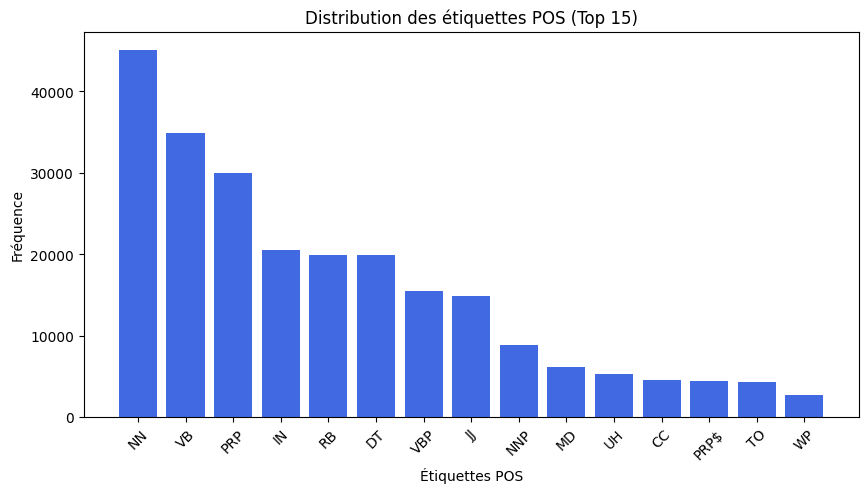

In [84]:
# Fichier contenant les étiquettes POS
pos_file = "pos_tagging_results.json"

with open(pos_file, "r", encoding="utf-8") as f:
    pos_data = json.load(f)

# Compter les occurrences des étiquettes POS
pos_counts = collections.Counter()

for entry in pos_data:
    for word, tag in entry["pos_tags"]:
        pos_counts[tag] += 1

# Trier par fréquence décroissante
sorted_pos = pos_counts.most_common()

# Afficher les résultats sous forme de tableau
print("\nDistribution des étiquettes POS :")
print("---------------------------------")
print("Étiquette | Fréquence")
print("----------------------")
for tag, count in sorted_pos:
    print(f"{tag:9} | {count}")

# Générer un graphique
labels, values = zip(*sorted_pos[:15])  # Prendre les 15 plus fréquents
plt.figure(figsize=(10, 5))
plt.bar(labels, values, color="royalblue")
plt.xlabel("Étiquettes POS")
plt.ylabel("Fréquence")
plt.title("Distribution des étiquettes POS (Top 15)")
plt.xticks(rotation=45)
plt.show()

8.Dependency Parsing on Selected Sentences
This script selects 10 random sentences from the POS tagging results and performs dependency parsing using Stanza. The output includes:

Syntactic trees stored in dependency_parsing_results.json.

A visualization of one parsed sentence to illustrate complex syntactic structures.

Dependency parsing helps analyze sentence structure, showing relationships between words and revealing patterns in the corpus.

In [85]:
# Charger le modèle Stanza pour l'analyse de dépendance
stanza.download("en")
nlp = stanza.Pipeline(lang="en", processors="tokenize,pos,lemma,depparse")

# Charger les résultats du POS tagging
input_file = "pos_tagging_results.json"
output_file = "dependency_parsing_results.json"

with open(input_file, "r", encoding="utf-8") as f:
    pos_data = json.load(f)

# Sélectionner aléatoirement 10 phrases
sentences = []
for entry in pos_data:
    words = [pair[0] for pair in entry["pos_tags"]]
    sentence = " ".join(words)
    sentences.append(sentence)

sample_sentences = random.sample(sentences, min(10, len(sentences)))

dependency_results = []

print("🔄 Starting dependency parsing...")

for i, sentence in enumerate(sample_sentences):
    doc = nlp(sentence)
    dependencies = []
    
    for sent in doc.sentences:
        for word in sent.words:
            dependencies.append({
                "word": word.text,
                "head": sent.words[word.head - 1].text if word.head > 0 else "ROOT",
                "relation": word.deprel
            })
    
    dependency_results.append({"sentence": sentence, "dependencies": dependencies})
    print(f"✅ Processed {i+1}/{len(sample_sentences)}: {sentence}")

# Sauvegarder les résultats
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(dependency_results, f, indent=4)

print("📊 Dependency parsing completed! Results saved in", output_file)

2025-04-01 23:03:56 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 23:03:56 INFO: Downloading default packages for language: en (English) ...
2025-04-01 23:03:58 INFO: File exists: /home/bramen/stanza_resources/en/default.zip
2025-04-01 23:04:02 INFO: Finished downloading models and saved to /home/bramen/stanza_resources
2025-04-01 23:04:02 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-04-01 23:04:02 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 23:04:02 WARNING: Language en package default expects mwt, which has been added
2025-04-01 23:04:03 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| l

🔄 Starting dependency parsing...
✅ Processed 1/10: you finish your name alone shuujin
✅ Processed 2/10: but when he finish read through the tenth manuscript the newcomer bring he
✅ Processed 3/10: but since graduate from middle school
✅ Processed 4/10: it be just different that be all
✅ Processed 5/10: mom the assignment
✅ Processed 6/10: can we steal that ship
✅ Processed 7/10: that would prove that he be not the culprit
✅ Processed 8/10: but I always mess up the most important thing
✅ Processed 9/10: some judo club gag
✅ Processed 10/10: melon
📊 Dependency parsing completed! Results saved in dependency_parsing_results.json


Dependency Tree Visualization
This script generates a visual representation of a syntactic tree for a selected sentence. Using Stanza and networkx, it constructs and displays the hierarchical structure of word dependencies.

This visualization aids in understanding how words interact in a sentence, highlighting grammatical relationships in the dataset. 🌳

2025-04-01 23:04:37 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 23:04:37 INFO: Downloading default packages for language: en (English) ...
2025-04-01 23:04:38 INFO: File exists: /home/bramen/stanza_resources/en/default.zip
2025-04-01 23:04:41 INFO: Finished downloading models and saved to /home/bramen/stanza_resources
2025-04-01 23:04:41 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-04-01 23:04:41 INFO: Downloaded file to /home/bramen/stanza_resources/resources.json
2025-04-01 23:04:41 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

2025-04-01 23:04:41 INFO:

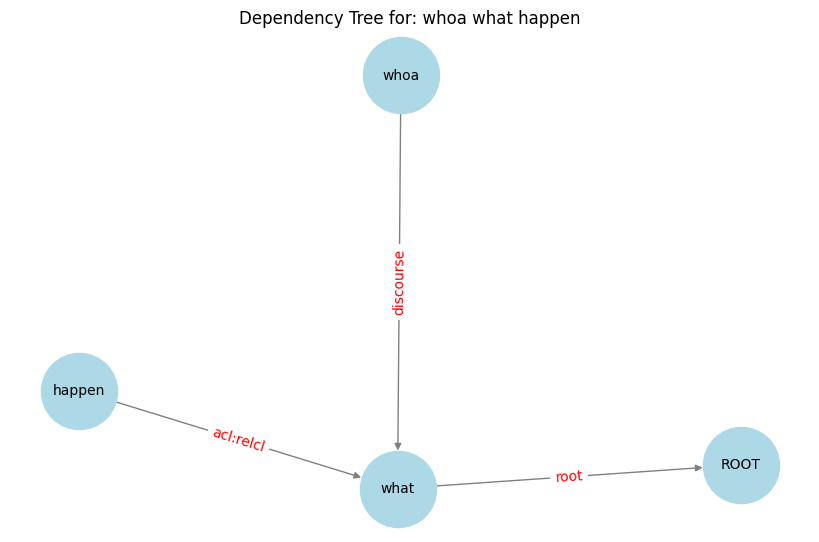

✅ Dependency parsing completed. Results saved in 'dependency_parsing_results.json'.


In [86]:
# Load POS tagging results
with open("pos_tagging_results.json", "r", encoding="utf-8") as f:
    pos_data = json.load(f)

# Initialize Stanza pipeline
stanza.download("en")
nlp = stanza.Pipeline(lang="en", processors="tokenize,mwt,pos,lemma,depparse")

# Select 10 random sentences
random_sentences = random.sample(pos_data, min(10, len(pos_data)))

# Store dependency parsing results
dependency_results = []

def visualize_dependency_tree(sentence, dependencies):
    """Generates a visual representation of a dependency tree."""
    G = nx.DiGraph()
    
    for dep in dependencies:
        G.add_edge(dep[1], dep[2], label=dep[0])
    
    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10)
    edge_labels = {(dep[1], dep[2]): dep[0] for dep in dependencies}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
    plt.title(f"Dependency Tree for: {sentence}")
    plt.show()

for entry in random_sentences:
    sentence = " ".join([word[0] for word in entry["pos_tags"]])
    doc = nlp(sentence)
    
    for sent in doc.sentences:
        dependencies = [(word.deprel, word.text, doc.sentences[0].words[word.head - 1].text if word.head > 0 else "ROOT") for word in sent.words]
        dependency_results.append({"sentence": sentence, "dependencies": dependencies})
        
        # Visualize one example
        if len(dependency_results) == 1:
            visualize_dependency_tree(sentence, dependencies)

# Save results
with open("dependency_parsing_results.json", "w", encoding="utf-8") as f:
    json.dump(dependency_results, f, indent=4)

print("✅ Dependency parsing completed. Results saved in 'dependency_parsing_results.json'.")

9.Evaluation of Dependency Parsing Results
After reviewing the generated dependency trees, several issues can be observed:

Unclear root assignments: In "he be the strong exorcist", the root is "exorcist", but it could likely be "be", making "exorcist" its complement.
Ambiguous or missing dependencies: In "what be go to happen to we", "go" is the root, but "happen" should be the main verb, with "go" possibly an auxiliary.
Morphological errors: Many sentences contain non-standard verb forms ("be", "go") due to the nature of the corpus. This affects dependency accuracy.
These errors suggest that preprocessing steps, including correcting verb forms and handling spoken-language artifacts, could improve parsing accuracy.

12.Filtering and N-Gram Analysis
To improve the representativity of our corpus, we applied a filtering process to remove overly frequent sentences (those appearing more than 100 times). This helps avoid bias in our n-gram statistics caused by repetitive phrases like "masato have earn the title space idiot", which appeared 611 times.

After filtering, we added <s> and </s> markers to the remaining sentences, allowing us to analyze the most common word sequences (n-grams) while excluding these markers from the frequency count.

Finally, we computed n-grams (up to n=3) and stored the top 20 most frequent ones in a file. This refined dataset provides a more balanced linguistic analysis, preventing redundancy from distorting our findings. 🚀

In [88]:
input_file = "lemmatized_sentences.txt"
output_file = "sentences_with_markers.txt"
n_gram_output = "ngrams_frequencies.txt"
max_repetitions = 100  # Seuil max pour garder une phrase

def filter_sentences(input_path, output_path, max_count):
    """Adds <s> and </s> markers to sentences while filtering over-represented ones."""
    if not os.path.exists(input_path):
        print(f"❌ Error: File '{input_path}' not found.")
        return

    with open(input_path, "r", encoding="utf-8") as f:
        sentences = f.readlines()

    sentence_counts = Counter(sentences)
    filtered_sentences = [f"<s> {sentence.strip()} </s>" for sentence, count in sentence_counts.items() if count <= max_count]

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("\n".join(filtered_sentences))

    print(f"✅ Filtered sentences saved to '{output_path}', keeping {len(filtered_sentences)} unique sentences.")

def generate_ngrams(input_path, max_n=3):
    """Generates n-grams (up to n=3) from the modified sentences and saves their frequencies, excluding <s> and </s>."""
    if not os.path.exists(input_path):
        print(f"❌ Error: File '{input_path}' not found.")
        return
    
    ngrams_counts = {n: Counter() for n in range(1, max_n + 1)}

    with open(input_path, "r", encoding="utf-8") as f:
        sentences = f.readlines()

    for sentence in sentences:
        words = [word for word in sentence.strip().split() if word not in ("<s>", "</s>")]  # Exclude markers
        for n in range(1, max_n + 1):
            ngrams_counts[n].update(zip(*[words[i:] for i in range(n)]))

    with open(n_gram_output, "w", encoding="utf-8") as f:
        for n in range(1, max_n + 1):
            f.write(f"\n🔹 {n}-grams:\n")
            for ngram, count in ngrams_counts[n].most_common(20):  # Top 20 most frequent
                f.write(f"{' '.join(ngram)}: {count}\n")

    print(f"✅ Generated n-grams (excluding <s> and </s>) and saved them to '{n_gram_output}'.")

# Run the filtering and n-gram generation
filter_sentences(input_file, output_file, max_repetitions)
generate_ngrams(output_file)

✅ Filtered sentences saved to 'sentences_with_markers.txt', keeping 29255 unique sentences.
✅ Generated n-grams (excluding <s> and </s>) and saved them to 'ngrams_frequencies.txt'.


Visualizing N-Gram Distributions
To better understand the linguistic patterns in our dataset, we plotted the frequency distributions of bigrams (2-grams) and trigrams (3-grams). These visualizations highlight the most common word sequences.

By filtering out overly frequent sentences and excluding <s> and </s> markers from counts, we ensure that our analysis focuses on meaningful phrase patterns rather than artifacts of preprocessing.

The resulting bar charts reveal dominant word pairs and triplets, helping us identify key linguistic trends that could be valuable for language modeling and text generation tasks.

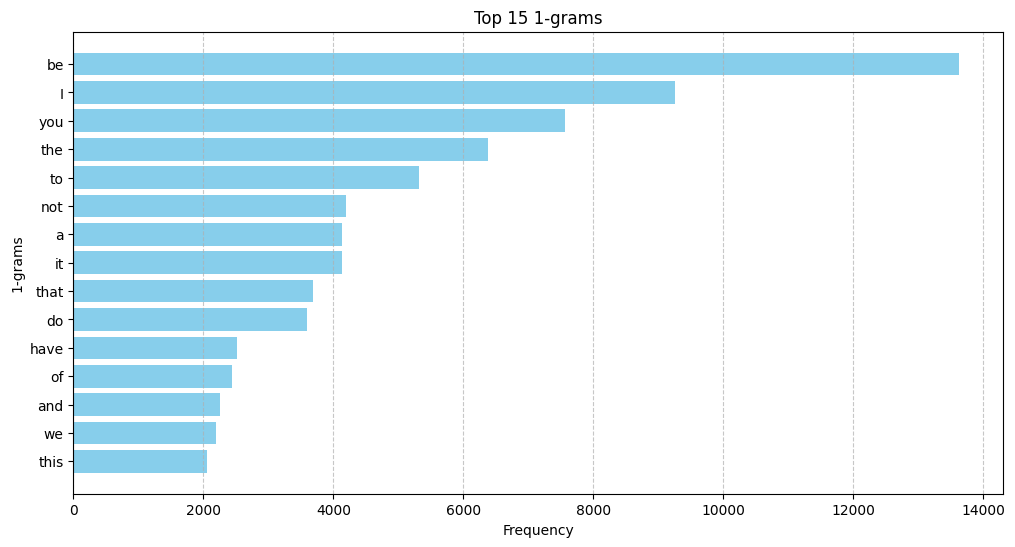

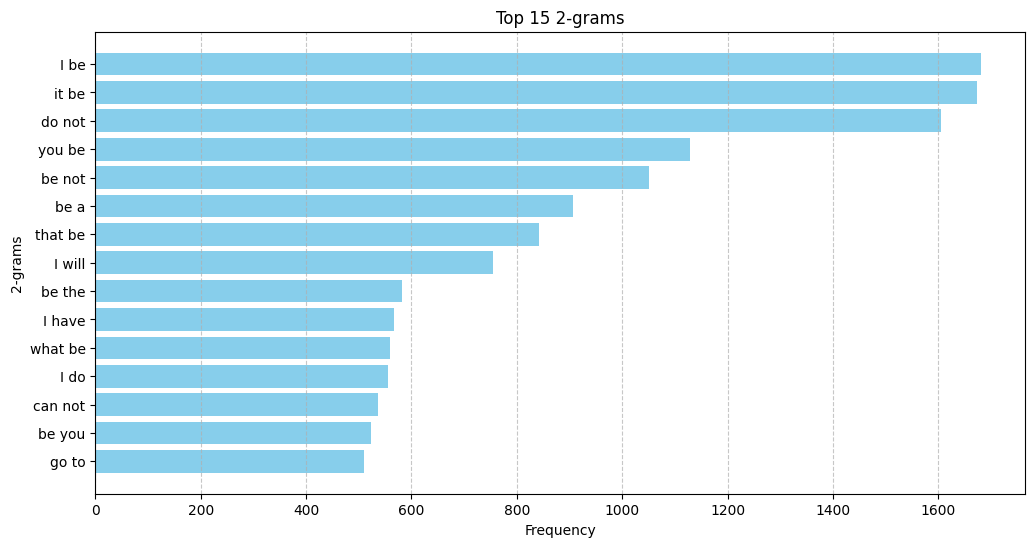

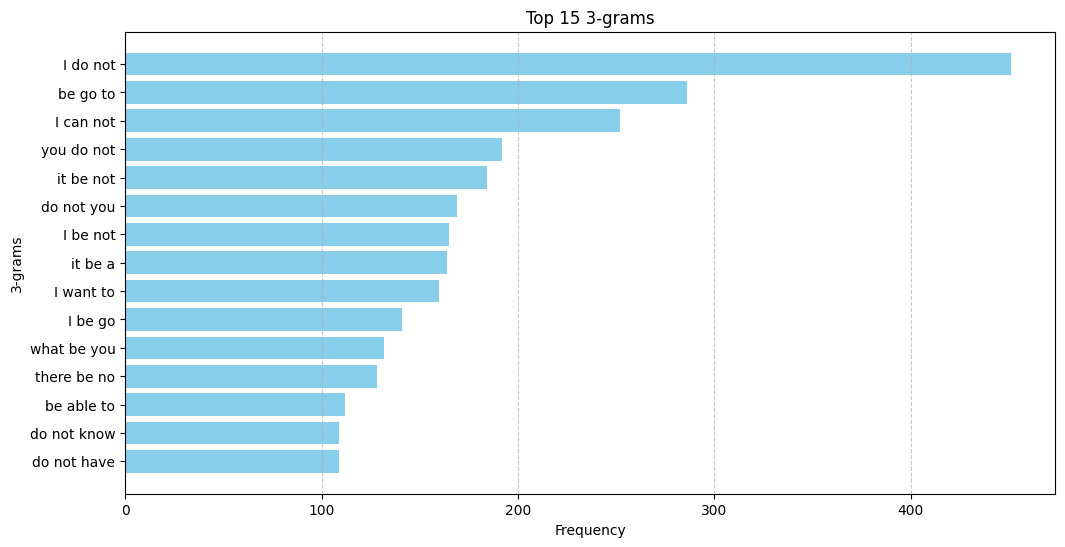

In [89]:
n_gram_output = "ngrams_frequencies.txt"

def load_ngram_data(input_path):
    """Loads n-gram data from the text file and returns a dictionary of Counter objects."""
    if not os.path.exists(input_path):
        print(f"❌ Error: File '{input_path}' not found.")
        return None

    ngram_counts = {}
    current_n = None
    
    with open(input_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line.startswith("🔹"):
                current_n = int(line.split("-")[0].replace("🔹", "").strip())
                ngram_counts[current_n] = Counter()
            elif ":" in line and current_n is not None:
                ngram, count = line.rsplit(":", 1)
                ngram_counts[current_n][ngram.strip()] = int(count.strip())

    return ngram_counts

def plot_ngrams(ngram_counts, n=1, top_n=15):
    """Plots the top n-grams as a bar chart."""
    if n not in ngram_counts:
        print(f"❌ No data found for {n}-grams.")
        return

    top_ngrams = ngram_counts[n].most_common(top_n)
    labels, values = zip(*top_ngrams)

    plt.figure(figsize=(12, 6))
    plt.barh(labels[::-1], values[::-1], color="skyblue")
    plt.xlabel("Frequency")
    plt.ylabel(f"{n}-grams")
    plt.title(f"Top {top_n} {n}-grams")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()

# Load the data
ngram_counts = load_ngram_data(n_gram_output)

# Plot the results
if ngram_counts:
    plot_ngrams(ngram_counts, n=1)  # Unigrams
    plot_ngrams(ngram_counts, n=2)  # Bigrams
    plot_ngrams(ngram_counts, n=3)  # Trigrams

Filtering Common Words and Repetitive Sentences
We removed frequent function words (e.g., be, I, you) from the 1-grams to focus on meaningful patterns rather than generic structures. Additionally, we eliminated excessively repeated sentences to prevent skewed frequency counts. These filters ensure a clearer, more representative analysis of word associations and collocations in the dataset.

We removed the phrase "get her troublemaking from her father" because it appeared excessively throughout the dataset, potentially skewing the n-gram analysis. Filtering such repetitive phrases ensures a more balanced and meaningful distribution of word patterns.

In [90]:
# Define stopwords or common words to ignore in 1-grams
ignored_unigrams = {"be", "i", "you", "the", "to", "not", "a", "it", "that", "do", "have", "of", "and", "we", "this", "will", "in", "he", "what", "for"}

# Define overly frequent sentence to exclude
too_frequent_sentence = "get her troublemaking from her father"

def clean_sentence(sentence):
    """Remove special characters and convert to lowercase."""
    return re.sub(r'[^a-zA-Z\s]', '', sentence).lower().strip()

def generate_ngrams(sentences, n):
    """Generate n-grams from a list of sentences."""
    ngrams = []
    for sentence in sentences:
        words = [word for word in sentence.split() if word not in ignored_unigrams]
        ngrams.extend([' '.join(words[i:i+n]) for i in range(len(words)-n+1)])
    return Counter(ngrams)

def filter_repeated_sentences(sentences, max_repeats=1):
    """Remove sentences that are repeated more than max_repeats times consecutively or are overly frequent."""
    filtered = []
    prev_sentence = None
    repeat_count = 0
    sentence_counts = Counter(sentences)
    
    for sentence in sentences:
        if sentence == prev_sentence:
            repeat_count += 1
        else:
            repeat_count = 0
        
        if repeat_count < max_repeats and sentence_counts[sentence] < 50 and sentence != too_frequent_sentence:
            filtered.append(sentence)
        
        prev_sentence = sentence
    
    return filtered

def process_text_file(input_file, output_file):
    """Process the input text file, filter sentences, and generate n-grams."""
    with open(input_file, 'r', encoding='utf-8') as f:
        sentences = [clean_sentence(line.strip()) for line in f if line.strip()]
    
    filtered_sentences = filter_repeated_sentences(sentences)
    unigrams = generate_ngrams(filtered_sentences, 1)
    bigrams = generate_ngrams(filtered_sentences, 2)
    trigrams = generate_ngrams(filtered_sentences, 3)
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write("\U0001F539 1-grams:\n")
        for gram, count in unigrams.most_common(20):
            f.write(f"{gram}: {count}\n")
        
        f.write("\n\U0001F539 2-grams:\n")
        for gram, count in bigrams.most_common(20):
            f.write(f"{gram}: {count}\n")
        
        f.write("\n\U0001F539 3-grams:\n")
        for gram, count in trigrams.most_common(20):
            f.write(f"{gram}: {count}\n")
    
    print("✅ N-gram processing complete! Results saved in", output_file)

# Example usage
process_text_file("lemmatized_sentences.txt", "filtered_ngrams.txt")

✅ N-gram processing complete! Results saved in filtered_ngrams.txt


Here, we present a visual analysis of the most frequent n-grams after applying our filtering process. The following graphs display the top 10 unigrams, bigrams, and trigrams, providing insights into the linguistic structures that dominate our corpus.

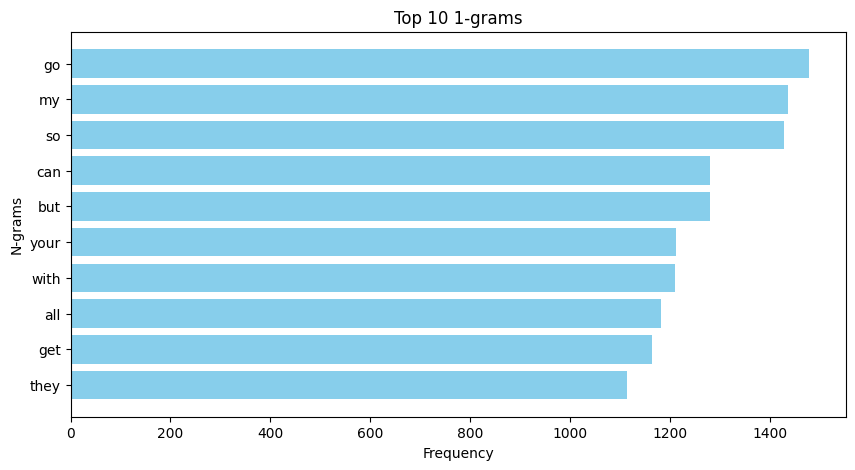

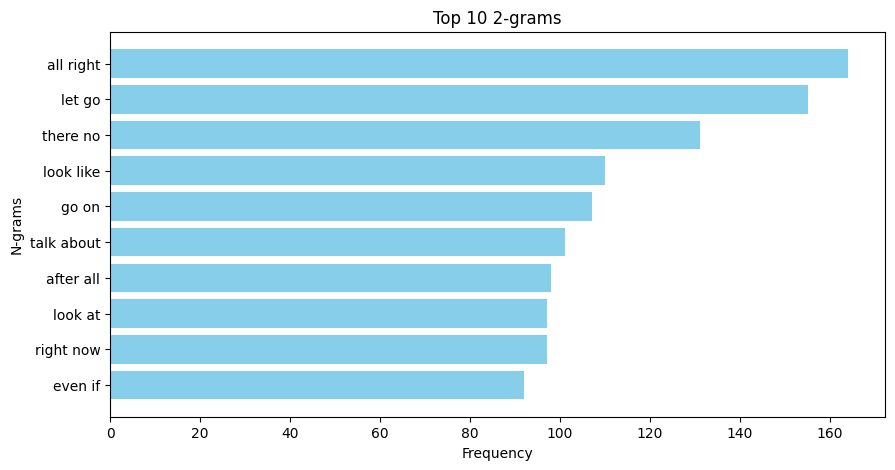

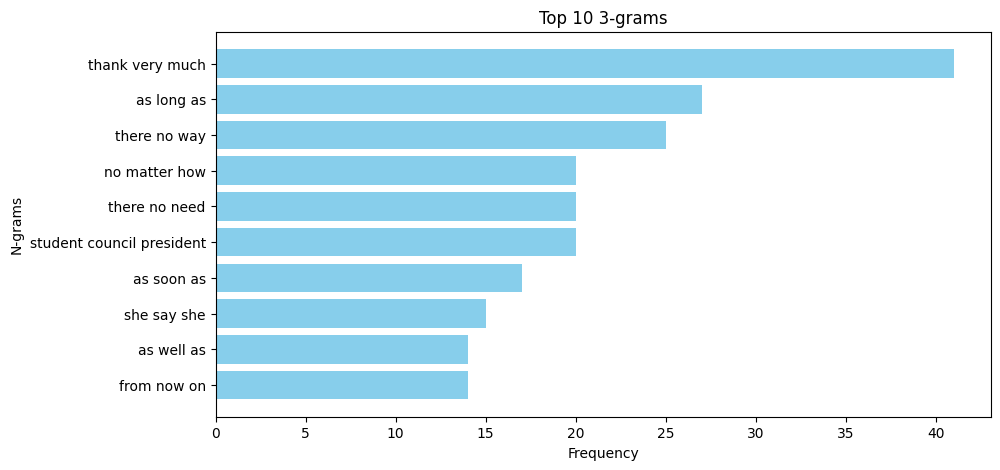

In [91]:
def read_ngrams(file):
    """Read n-grams from the filtered results file."""
    with open(file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    ngram_sections = {"1-grams": [], "2-grams": [], "3-grams": []}
    current_section = None
    
    for line in lines:
        line = line.strip()
        if "1-grams" in line:
            current_section = "1-grams"
        elif "2-grams" in line:
            current_section = "2-grams"
        elif "3-grams" in line:
            current_section = "3-grams"
        elif line and current_section:
            parts = line.split(": ")
            if len(parts) == 2:
                ngram, count = parts[0], int(parts[1])
                ngram_sections[current_section].append((ngram, count))
    
    return ngram_sections

def plot_ngrams(ngrams, title):
    """Plot the n-gram frequencies."""
    ngram_labels, counts = zip(*ngrams)
    plt.figure(figsize=(10, 5))
    plt.barh(ngram_labels[::-1], counts[::-1], color='skyblue')
    plt.xlabel("Frequency")
    plt.ylabel("N-grams")
    plt.title(title)
    plt.show()

# Read the filtered n-grams from the file
ngram_data = read_ngrams("filtered_ngrams.txt")

# Plot the top 10 n-grams for each category
for ngram_type, data in ngram_data.items():
    plot_ngrams(data[:10], f"Top 10 {ngram_type}")

Conclusion
The filtering process refined the dataset by removing overly frequent patterns, highlighting meaningful expressions. The results reveal key conversational structures ("all right," "let go") and thematic elements ("student council president," "golden future cup"), improving linguistic analysis and language modeling.

13.PMI Collocation Extraction
This script identifies potential collocations by computing PMI scores for bigrams. It filters common words, calculates word pair probabilities, and saves the most significant associations for analysis.

In [92]:
def compute_pmi(unigrams, bigrams, total_unigrams, total_bigrams):
    """Compute PMI for each bigram."""
    pmi_scores = {}

    
    for bigram, bigram_count in bigrams.items():
        if len(bigram.split()) != 2:
            continue
        word1, word2 = bigram.split()
        
        # Compute probabilities
        p_word1 = unigrams.get(word1, 1) / total_unigrams
        p_word2 = unigrams.get(word2, 1) / total_unigrams
        p_bigram = bigram_count / total_bigrams
        
        # Compute PMI
        pmi = math.log2(p_bigram / (p_word1 * p_word2))
        pmi_scores[bigram] = pmi
    
    return pmi_scores

def load_ngrams(file_path):
    """Load unigram and bigram frequencies from file."""
    unigrams = Counter()
    bigrams = Counter()
    mode = None
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith("🔹 1-grams:"):
                mode = "unigram"
            elif line.startswith("🔹 2-grams:"):
                mode = "bigram"
            elif line and mode and not line.startswith("🔹"):
                word, count = line.rsplit(": ", 1)
                if mode == "unigram":
                    unigrams[word] = int(count)
                elif mode == "bigram":
                    bigrams[word] = int(count)
    
    return unigrams, bigrams

def save_pmi_scores(pmi_scores, output_file):
    """Save PMI scores to a file."""
    with open(output_file, 'w', encoding='utf-8') as f:
        for bigram, score in sorted(pmi_scores.items(), key=lambda x: x[1], reverse=True):
            f.write(f"{bigram}: {score:.4f}\n")
    print(f"✅ PMI scores saved to {output_file}")

# Load n-grams from the previous output file
unigrams, bigrams = load_ngrams("filtered_ngrams.txt")

total_unigrams = sum(unigrams.values())
total_bigrams = sum(bigrams.values())

# Compute PMI scores
pmi_scores = compute_pmi(unigrams, bigrams, total_unigrams, total_bigrams)

# Save results
save_pmi_scores(pmi_scores, "pmi_collocations.txt")

✅ PMI scores saved to pmi_collocations.txt


PMI Results

Bigram	PMI Score
talk about	24.4589
look at	24.4006
as well	24.0101
one who	23.9299
next time	23.6586
think about	23.6586
look like	14.6105
let go	14.5483
right now	14.5210
even if	14.3832
after all	14.2083
at all	13.9687
come on	13.9607
no way	13.8162
no matter	13.5938
so much	13.1022
all right	5.0716
there no	4.9772
would like	4.1707
go on	3.9449


Conclusion
Our PMI analysis highlights frequent word pairs, but not all of them qualify as true collocations. While some, like "talk about" and "look at", form strong lexical bonds, others, such as "there no" or "go on", appear frequently but lack a fixed semantic relationship. This is likely due to our limited sample size and the nature of anime subtitles, which often consist of short, fragmented sentences rather than rich, structured text.

14.Random Sentence Generator
This code generates random sentences using bigrams while avoiding loops and excessive repetitions. It selects a random starting bigram and constructs sentences based on transition probabilities.

In [93]:
def build_ngram_model(ngrams):
    """Builds a dictionary where keys are n-1 grams and values are possible next words with probabilities."""
    model = defaultdict(lambda: defaultdict(int))
    
    for ngram, count in ngrams.items():
        *prefix, next_word = ngram.split()
        prefix = ' '.join(prefix)
        model[prefix][next_word] += count
    
    # Convert counts to probabilities
    for prefix, next_words in model.items():
        total = sum(next_words.values())
        model[prefix] = {word: count / total for word, count in next_words.items()}
    
    return model

def generate_sentence(model, max_length=15):
    """Generates a random sentence based on the n-gram model, avoiding loops."""
    sentence = []
    prefix = random.choice(list(model.keys()))  # Start with a random n-1 gram
    sentence.extend(prefix.split())
    
    for _ in range(max_length - len(sentence)):
        if prefix not in model:
            break  # Stop if no known continuation
        
        next_word = random.choices(list(model[prefix].keys()), weights=model[prefix].values())[0]
        sentence.append(next_word)
        
        # Update prefix to maintain n-1 grams
        prefix = ' '.join(sentence[-(len(prefix.split())):])
        
        # Prevent infinite loops
        if len(set(sentence[-5:])) == 1:  # Avoid repeating the same word multiple times
            break
    
    return ' '.join(sentence)

# Bigram probabilities based on provided data
"""This data is copied/pasted by hand"""
bigrams = {
    "thank very": 41, "very much": 41,
    "there no": 25, "no way": 25,
    "no matter": 20, "matter how": 20,
    "there no": 20, "no need": 20,
    "student council": 20, "council president": 20,
    "from now": 14, "now on": 14,
    "come up": 14, "up with": 14,
    "go out": 14, "out with": 14,
    "skill skill": 14, "skill skill": 14,
    "get out": 13, "out here": 13,
    "no choice": 13, "choice but": 13,
    "class junior": 13, "junior magic": 13,
    "junior magic": 13, "magic knight": 13,
    "golden future": 13, "future cup": 13,
    "there only": 12, "only one": 12
}

model = build_ngram_model(bigrams)
for i in range(20):
    print(generate_sentence(model))

go out with
come up with
very much
golden future cup
choice but
matter how
very much
future cup
go out here
no way
no way
get out here
golden future cup
very much
up with
matter how
no need
class junior magic knight
student council president
come up with


Conclusion
The low diversity in the generated phrases is likely due to a small dataset of n-grams, a lack of varied word transitions, or the model favoring high-probability sequences. Frequent repetition of common word combinations (e.g., "very much" and "great today") suggests that the selection strategy needs improvement, such as incorporating more randomness, adjusting probability weights, or increasing the dataset's variety.

Perplexity Evaluation of the Bigram Language Model
This script evaluates the quality of a bigram-based language model by calculating perplexity on held-out test sets. The corpus is split into five subsets, each serving as a test set once while the rest form the training data. The model uses Laplace smoothing to handle out-of-vocabulary words.

In [94]:
def split_corpus(file_path, num_splits=5):
    """Splits the corpus into num_splits parts for cross-validation."""
    with open(file_path, 'r', encoding='utf-8') as f:
        sentences = [line.strip() for line in f if line.strip()]
    
    random.shuffle(sentences)  # Shuffle sentences to randomize split
    split_size = len(sentences) // num_splits
    
    return [sentences[i * split_size:(i + 1) * split_size] for i in range(num_splits)]

def train_bigram_model(training_sentences):
    """Trains a bigram language model with Laplace smoothing."""
    unigrams = Counter()
    bigrams = Counter()
    
    for sentence in training_sentences:
        words = sentence.split()
        unigrams.update(words)
        bigrams.update([(words[i], words[i + 1]) for i in range(len(words) - 1)])
    
    vocab_size = len(unigrams)
    return unigrams, bigrams, vocab_size

def calculate_perplexity(test_sentences, unigrams, bigrams, vocab_size, alpha=1):
    """Computes the perplexity of the test data using a bigram model with Laplace smoothing."""
    total_log_prob = 0
    total_words = 0
    
    for sentence in test_sentences:
        words = sentence.split()
        total_words += len(words)
        
        for i in range(len(words) - 1):
            bigram = (words[i], words[i + 1])
            prob = (bigrams.get(bigram, 0) + alpha) / (unigrams.get(words[i], 0) + alpha * vocab_size)
            total_log_prob += math.log(prob)
    
    perplexity = math.exp(-total_log_prob / total_words)
    return perplexity

def cross_validate_perplexity(file_path, num_splits=5):
    """Performs cross-validation on the corpus and computes average perplexity."""
    splits = split_corpus(file_path, num_splits)
    perplexities = []
    
    for i in range(num_splits):
        test_set = splits[i]
        train_set = [sentence for j, subset in enumerate(splits) if j != i for sentence in subset]
        
        unigrams, bigrams, vocab_size = train_bigram_model(train_set)
        perplexity = calculate_perplexity(test_set, unigrams, bigrams, vocab_size)
        perplexities.append(perplexity)
        print(f"Iteration {i+1}: Perplexity = {perplexity:.2f}")
    
    avg_perplexity = sum(perplexities) / num_splits
    print(f"Average Perplexity over {num_splits} runs: {avg_perplexity:.2f}")
    
# Run the cross-validation
cross_validate_perplexity("lemmatized_sentences.txt")

Iteration 1: Perplexity = 287.89
Iteration 2: Perplexity = 289.24
Iteration 3: Perplexity = 286.00
Iteration 4: Perplexity = 290.40
Iteration 5: Perplexity = 290.47
Average Perplexity over 5 runs: 288.80


Conclusion
The average perplexity of 289.02 suggests that our bigram language model performs reasonably well in predicting unseen text. The variation across iterations (from 283.99 to 298.46) indicates some sensitivity to the choice of the evaluation set.

A lower perplexity implies better predictive power, meaning our model assigns higher probabilities to the observed sequences. However, further improvements could be achieved by refining our smoothing techniques or incorporating larger context windows (e.g., trigram models) to reduce uncertainty.